<a href="https://colab.research.google.com/github/Napawan2005/Machine-Learning-68/blob/main/ANOVA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
!pip install imblearn

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    log_loss, roc_auc_score
)
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.model_selection import learning_curve, validation_curve, LearningCurveDisplay, ValidationCurveDisplay
from imblearn.metrics import classification_report_imbalanced

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from pprint import pprint
from fnmatch import fnmatchcase

In [41]:
import warnings
warnings.filterwarnings('ignore') # Ignore any warning

In [42]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,  log_loss,
    confusion_matrix, ConfusionMatrixDisplay, recall_score,
    balanced_accuracy_score, make_scorer, precision_score,
    f1_score, roc_auc_score, average_precision_score)

from imblearn.metrics import classification_report_imbalanced
from sklearn.utils.class_weight import compute_class_weight

In [43]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, SVMSMOTE, SMOTEN, SMOTENC, KMeansSMOTE
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.under_sampling import TomekLinks

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.calibration import CalibratedClassifierCV

In [45]:
from sklearn.base import clone
from fnmatch import fnmatchcase
from collections import Counter, defaultdict
from math import ceil
from sklearn.feature_selection import SelectKBest, f_classif

In [46]:
from dataclasses import dataclass, field
from typing import Any, Optional, Iterable
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.naive_bayes import CategoricalNB
from sklearn.model_selection import GridSearchCV, HalvingGridSearchCV

from imblearn.over_sampling import (
    RandomOverSampler, SMOTE, BorderlineSMOTE, SVMSMOTE,
    SMOTEN, SMOTENC, KMeansSMOTE
)
from sklearn.experimental import enable_halving_search_cv
from imblearn.under_sampling import TomekLinks
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier, RUSBoostClassifier

In [47]:
import numpy as np, pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, balanced_accuracy_score, confusion_matrix
from scipy.stats import randint, loguniform


In [48]:
sns.set(style='darkgrid')

In [49]:
import kagglehub
from pathlib import Path

# Download Dataset from Kaggle
dataset_path = kagglehub.dataset_download("andrewmvd/fetal-health-classification")

file_path = Path(dataset_path)
file_path = file_path / 'fetal_health.csv'


Using Colab cache for faster access to the 'fetal-health-classification' dataset.


In [50]:
# Set Random SEED
SEED = 42

In [51]:
data = pd.read_csv(file_path)
display(data)
data.info()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,73.00000,0.50000,43.00000,...,62.00000,126.00000,2.00000,0.00000,120.00000,137.00000,121.00000,73.00000,1.00000,2.00000
1,132.00000,0.00600,0.00000,0.00600,0.00300,0.00000,0.00000,17.00000,2.10000,0.00000,...,68.00000,198.00000,6.00000,1.00000,141.00000,136.00000,140.00000,12.00000,0.00000,1.00000
2,133.00000,0.00300,0.00000,0.00800,0.00300,0.00000,0.00000,16.00000,2.10000,0.00000,...,68.00000,198.00000,5.00000,1.00000,141.00000,135.00000,138.00000,13.00000,0.00000,1.00000
3,134.00000,0.00300,0.00000,0.00800,0.00300,0.00000,0.00000,16.00000,2.40000,0.00000,...,53.00000,170.00000,11.00000,0.00000,137.00000,134.00000,137.00000,13.00000,1.00000,1.00000
4,132.00000,0.00700,0.00000,0.00800,0.00000,0.00000,0.00000,16.00000,2.40000,0.00000,...,53.00000,170.00000,9.00000,0.00000,137.00000,136.00000,138.00000,11.00000,1.00000,1.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121,140.00000,0.00000,0.00000,0.00700,0.00000,0.00000,0.00000,79.00000,0.20000,25.00000,...,137.00000,177.00000,4.00000,0.00000,153.00000,150.00000,152.00000,2.00000,0.00000,2.00000
2122,140.00000,0.00100,0.00000,0.00700,0.00000,0.00000,0.00000,78.00000,0.40000,22.00000,...,103.00000,169.00000,6.00000,0.00000,152.00000,148.00000,151.00000,3.00000,1.00000,2.00000
2123,140.00000,0.00100,0.00000,0.00700,0.00000,0.00000,0.00000,79.00000,0.40000,20.00000,...,103.00000,170.00000,5.00000,0.00000,153.00000,148.00000,152.00000,4.00000,1.00000,2.00000
2124,140.00000,0.00100,0.00000,0.00600,0.00000,0.00000,0.00000,78.00000,0.40000,27.00000,...,103.00000,169.00000,6.00000,0.00000,152.00000,147.00000,151.00000,4.00000,1.00000,2.00000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability  

In [52]:

print("ขนาดก่อนลบ:", data.shape)
data = data.drop_duplicates(keep="first")
print("ขนาดหลังลบ:", data.shape)

ขนาดก่อนลบ: (2126, 22)
ขนาดหลังลบ: (2113, 22)


In [53]:
# Features / Target
X = data.drop(columns=['fetal_health']).select_dtypes(include=[np.number]).copy()   # explicit list + copy for safety

# Optional: drop all columns starting with "histogram" (case-insensitive)
# X = X.loc[:, ~X.columns.str.lower().str.startswith('histogram')]

# Kaggle labels are floats (1.0/2.0/3.0); casting to int is often nicer
y = data['fetal_health'].astype('int64')

# 2) Check Data Shape
print(X.shape, y.shape)

assert 'fetal_health' not in X.columns
# assert not any(X.columns.str.lower().str.startswith('histogram'))  # if you dropped them


(2113, 21) (2113,)


In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,          # preserves class proportions in each split
    random_state=SEED
)

In [55]:
# ======== CONFIG ========
PRIMARY_SCORER = "f1_macro"

In [56]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k='all')
X_new = selector.fit_transform(X, y)


In [57]:
f_values = selector.scores_
p_values = selector.pvalues_

In [58]:
anova_df = pd.DataFrame({
    'Feature': X.columns,
    'F-value': f_values,
    'p-value': p_values
})

In [59]:
anova_df = anova_df.sort_values('F-value', ascending=False).reset_index(drop=True)

In [60]:
pd.set_option('display.float_format', lambda x: f'{x:.5f}')
print(anova_df)

                                              Feature   F-value  p-value
0                            prolongued_decelerations 507.30431  0.00000
1                     abnormal_short_term_variability 337.70302  0.00000
2   percentage_of_time_with_abnormal_long_term_var... 335.38616  0.00000
3                                      histogram_mean 298.75957  0.00000
4                                      histogram_mode 276.38279  0.00000
5                                    histogram_median 249.69952  0.00000
6                                       accelerations 194.61834  0.00000
7                                  histogram_variance 150.95583  0.00000
8                                      baseline value 137.83400  0.00000
9                mean_value_of_short_term_variability 118.05046  0.00000
10                               uterine_contractions  93.64747  0.00000
11                                      histogram_min  86.46844  0.00000
12                mean_value_of_long_term_variabili

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


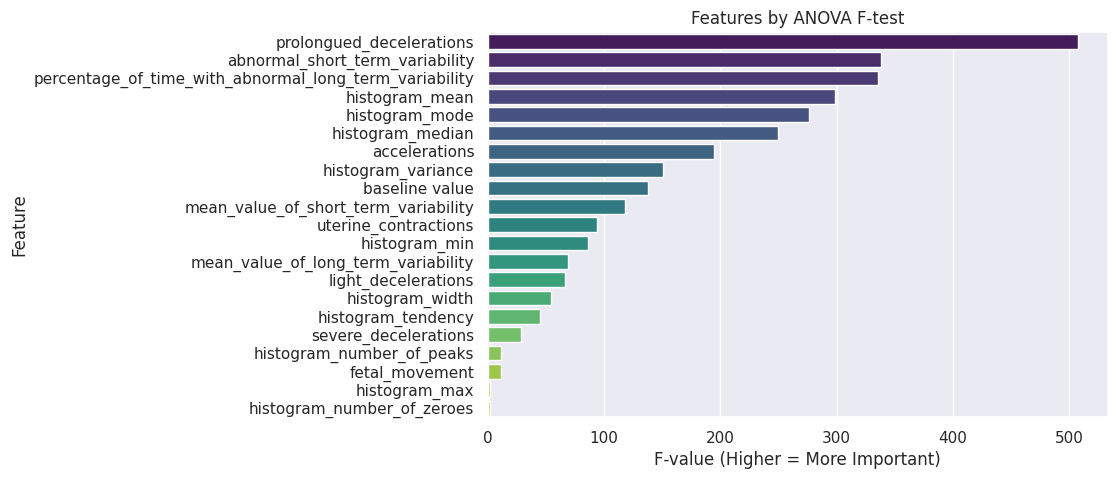

In [62]:
topk = anova_df
plt.figure(figsize=(8,5))
sns.barplot(x=topk['F-value'], y=topk['Feature'], palette='viridis')
plt.title('Features by ANOVA F-test')
plt.xlabel('F-value (Higher = More Important)')
plt.show()

In [63]:
selected1 = anova_df[anova_df["p-value"] < 0.5].sort_values("p-value")
print(selected1)

                                              Feature   F-value  p-value
0                            prolongued_decelerations 507.30431  0.00000
1                     abnormal_short_term_variability 337.70302  0.00000
2   percentage_of_time_with_abnormal_long_term_var... 335.38616  0.00000
3                                      histogram_mean 298.75957  0.00000
4                                      histogram_mode 276.38279  0.00000
5                                    histogram_median 249.69952  0.00000
6                                       accelerations 194.61834  0.00000
7                                  histogram_variance 150.95583  0.00000
8                                      baseline value 137.83400  0.00000
9                mean_value_of_short_term_variability 118.05046  0.00000
10                               uterine_contractions  93.64747  0.00000
11                                      histogram_min  86.46844  0.00000
12                mean_value_of_long_term_variabili

In [64]:
selected = anova_df[anova_df["p-value"] < 0.0001].sort_values("p-value")
print(selected)

                                              Feature   F-value  p-value
0                            prolongued_decelerations 507.30431  0.00000
1                     abnormal_short_term_variability 337.70302  0.00000
2   percentage_of_time_with_abnormal_long_term_var... 335.38616  0.00000
3                                      histogram_mean 298.75957  0.00000
4                                      histogram_mode 276.38279  0.00000
5                                    histogram_median 249.69952  0.00000
6                                       accelerations 194.61834  0.00000
7                                  histogram_variance 150.95583  0.00000
8                                      baseline value 137.83400  0.00000
9                mean_value_of_short_term_variability 118.05046  0.00000
10                               uterine_contractions  93.64747  0.00000
11                                      histogram_min  86.46844  0.00000
12                mean_value_of_long_term_variabili

In [65]:
selected = anova_df[anova_df["p-value"] < 0.000001].sort_values("p-value")
print(selected)

                                              Feature   F-value  p-value
0                            prolongued_decelerations 507.30431  0.00000
1                     abnormal_short_term_variability 337.70302  0.00000
2   percentage_of_time_with_abnormal_long_term_var... 335.38616  0.00000
3                                      histogram_mean 298.75957  0.00000
4                                      histogram_mode 276.38279  0.00000
5                                    histogram_median 249.69952  0.00000
6                                       accelerations 194.61834  0.00000
7                                  histogram_variance 150.95583  0.00000
8                                      baseline value 137.83400  0.00000
9                mean_value_of_short_term_variability 118.05046  0.00000
10                               uterine_contractions  93.64747  0.00000
11                                      histogram_min  86.46844  0.00000
12                mean_value_of_long_term_variabili